## 1. Setup & Imports

In [5]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.statespace.sarimax import SARIMAX

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)

## 2. Data Loading & Initial Inspection

In [6]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")
print('Shape:', df.shape)
df.head()

Shape: (2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [8]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [9]:
print('Missing values per column:')
print(df.isna().sum())
print('\nDuplicate rows:', df.duplicated().sum())
print('\nUnique Regions:', df['Region'].unique())
print('Unique Models:', df['Model'].unique())
print('Unique Source Types:', df['Source_Type'].unique())


Missing values per column:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Duplicate rows: 0

Unique Regions: ['Europe' 'Asia' 'North America' 'Middle East']
Unique Models: ['Model S' 'Model X' 'Model 3' 'Model Y' 'Cybertruck']
Unique Source Types: ['Interpolated (Month)' 'Official (Quarter)' 'Estimated (Region)']


## 3. Preprocessing


In [10]:
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str) + '-01')
df = df.sort_values('Date').reset_index(drop=True)

num_cols = ['Estimated_Deliveries','Production_Units','Avg_Price_USD','CO2_Saved_tons','Charging_Stations']
for c in num_cols:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((df[c] < lo) | (df[c] > hi)).sum()
    print(f'{c}: {n_out} potential outliers (IQR method)')


Estimated_Deliveries: 12 potential outliers (IQR method)
Production_Units: 12 potential outliers (IQR method)
Avg_Price_USD: 0 potential outliers (IQR method)
CO2_Saved_tons: 45 potential outliers (IQR method)
Charging_Stations: 0 potential outliers (IQR method)


## 4. Exploratory Data Analysis

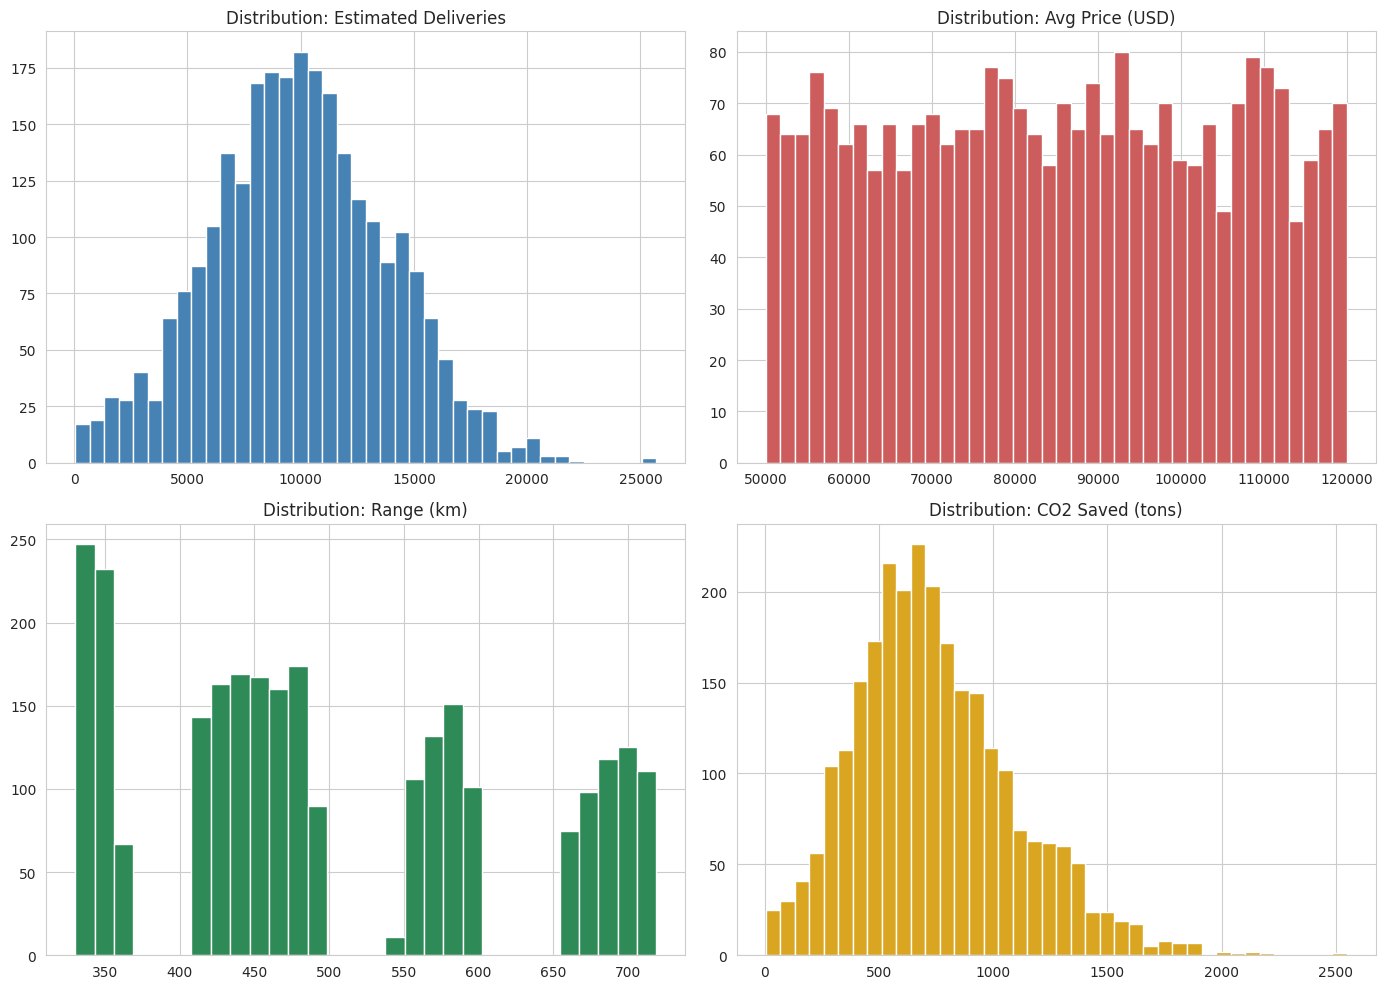

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
df['Estimated_Deliveries'].hist(bins=40, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Distribution: Estimated Deliveries')
df['Avg_Price_USD'].hist(bins=40, ax=axes[0,1], color='indianred')
axes[0,1].set_title('Distribution: Avg Price (USD)')
df['Range_km'].hist(bins=30, ax=axes[1,0], color='seagreen')
axes[1,0].set_title('Distribution: Range (km)')
df['CO2_Saved_tons'].hist(bins=40, ax=axes[1,1], color='goldenrod')
axes[1,1].set_title('Distribution: CO2 Saved (tons)')
plt.tight_layout()
plt.show()


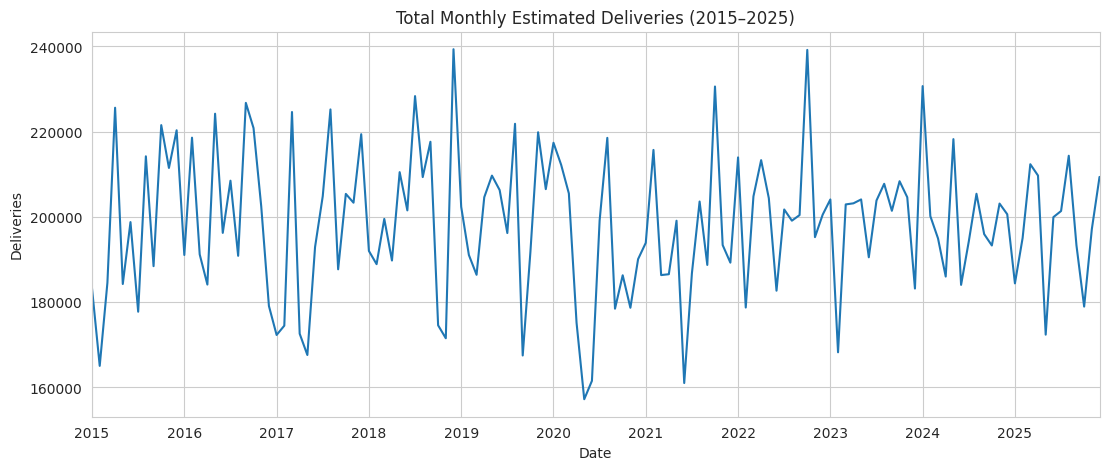

In [12]:
monthly_total = df.groupby('Date')['Estimated_Deliveries'].sum()
plt.figure(figsize=(13,5))
monthly_total.plot()
plt.title('Total Monthly Estimated Deliveries (2015–2025)')
plt.ylabel('Deliveries')
plt.xlabel('Date')
plt.show()


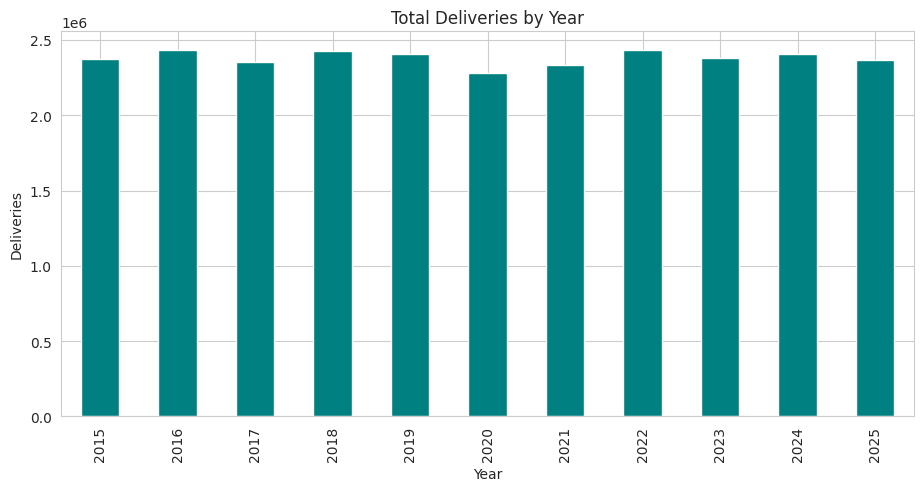

In [13]:
yearly = df.groupby(['Year'])['Estimated_Deliveries'].sum()
plt.figure(figsize=(11,5))
yearly.plot(kind='bar', color='teal')
plt.title('Total Deliveries by Year')
plt.ylabel('Deliveries')
plt.show()


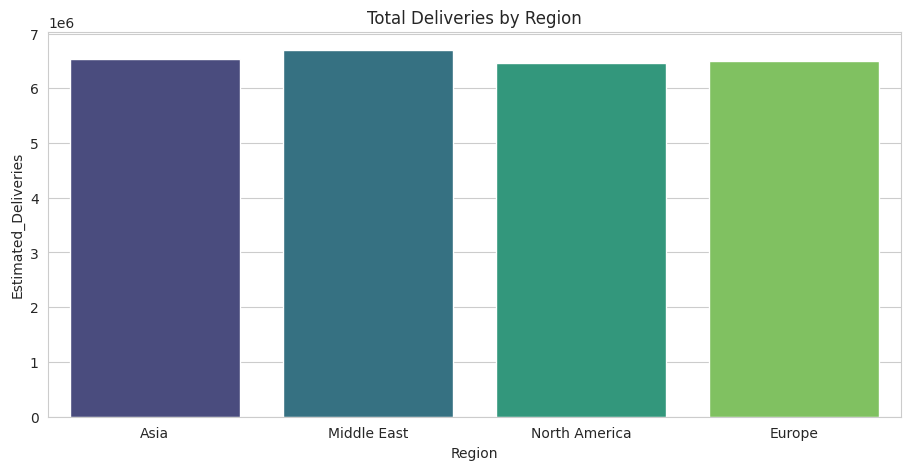

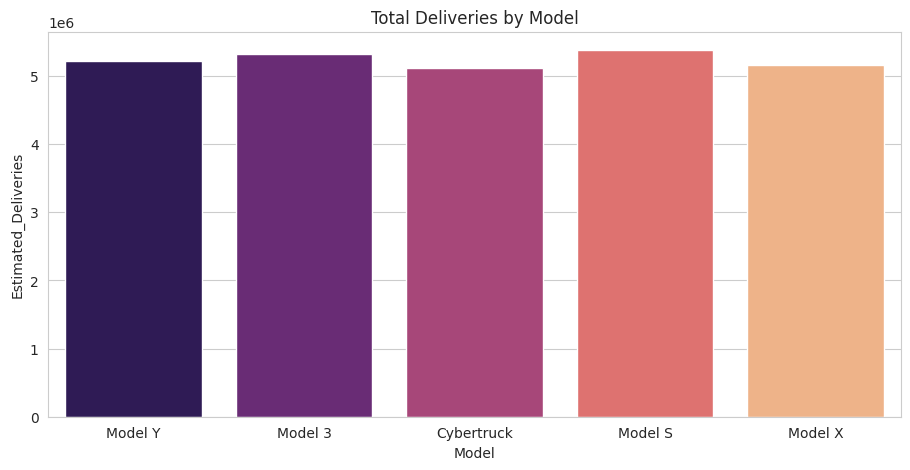

In [14]:
plt.figure(figsize=(11,5))
sns.barplot(data=df, x='Region', y='Estimated_Deliveries', estimator=sum, errorbar=None, palette='viridis')
plt.title('Total Deliveries by Region')
plt.show()
plt.figure(figsize=(11,5))
sns.barplot(data=df, x='Model', y='Estimated_Deliveries', estimator=sum, errorbar=None, palette='magma')
plt.title('Total Deliveries by Model')
plt.show()



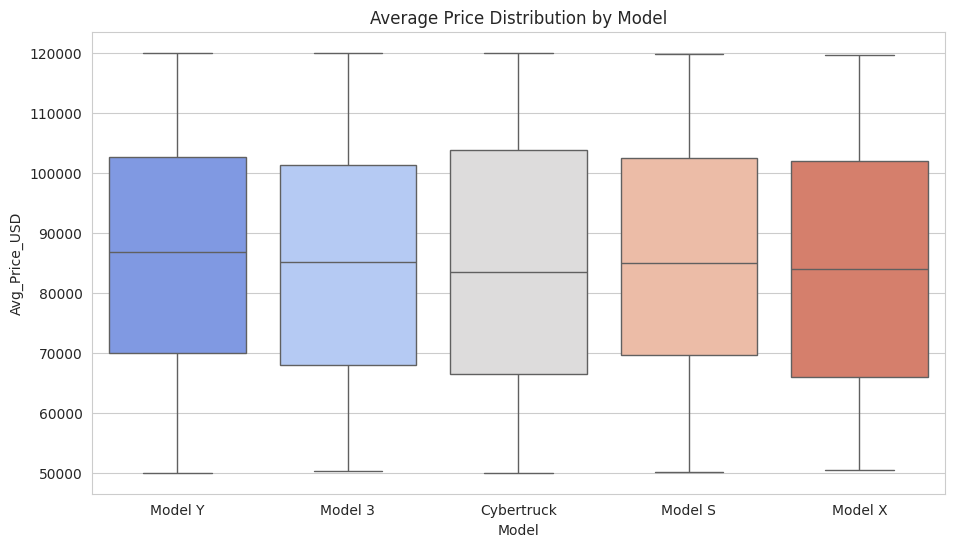

In [15]:
plt.figure(figsize=(11,6))
sns.boxplot(data=df, x='Model', y='Avg_Price_USD', palette='coolwarm')
plt.title('Average Price Distribution by Model')
plt.show()


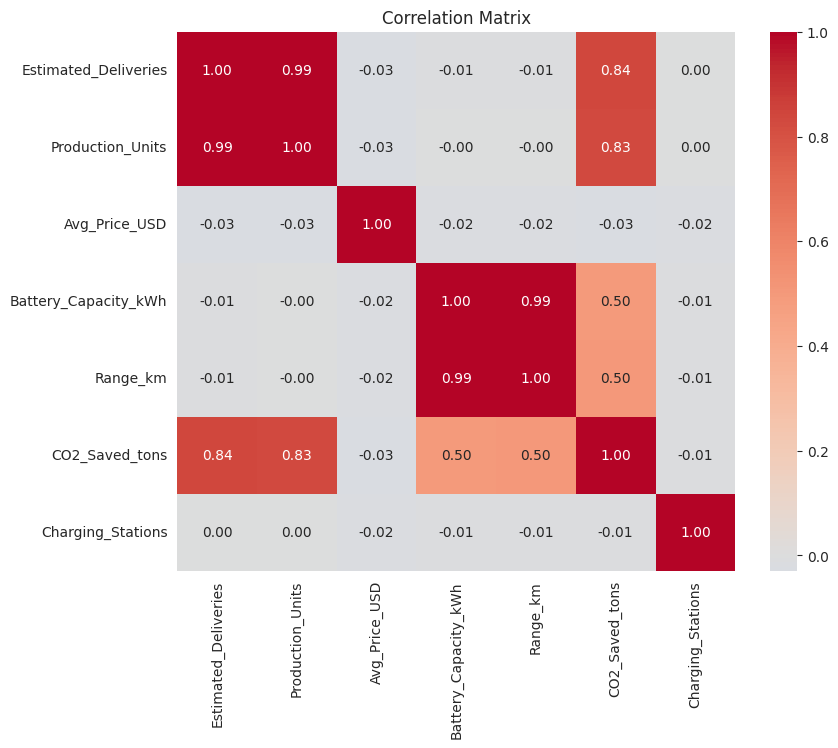

In [16]:
corr = df[['Estimated_Deliveries','Production_Units','Avg_Price_USD','Battery_Capacity_kWh',
           'Range_km','CO2_Saved_tons','Charging_Stations']].corr()
plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

## 5. Feature Engineering

In [17]:
df['Quarter'] = df['Date'].dt.quarter
df['Months_since_start'] = (df['Year'] - df['Year'].min()) * 12 + df['Month']
df['Production_Efficiency'] = df['Estimated_Deliveries'] / df['Production_Units']
df['Price_per_kWh'] = df['Avg_Price_USD'] / df['Battery_Capacity_kWh']
df['Range_per_kWh'] = df['Range_km'] / df['Battery_Capacity_kWh']
df['Month_sin'] = np.sin(2*np.pi*df['Month']/12)
df['Month_cos'] = np.cos(2*np.pi*df['Month']/12)

df[['Date','Quarter','Months_since_start','Production_Efficiency','Price_per_kWh','Range_per_kWh']].head()


,Date,Quarter,Months_since_start,Production_Efficiency,Price_per_kWh,Range_per_kWh
0,2015-01-01,1,1,0.896363,919.718833,5.666667
1,2015-01-01,1,1,0.897585,892.894000,5.880000
2,2015-01-01,1,1,0.942102,1714.809667,5.600000
3,2015-01-01,1,1,0.936048,1280.028293,5.597561
4,2015-01-01,1,1,0.959629,1073.033293,5.560976


## 6. Regression Modeling



In [18]:
target = 'Estimated_Deliveries'
num_features = ['Avg_Price_USD','Battery_Capacity_kWh','Range_km','CO2_Saved_tons',
                'Charging_Stations','Price_per_kWh','Range_per_kWh',
                'Months_since_start','Quarter','Month_sin','Month_cos']
cat_features = ['Region','Model','Source_Type']

X = df[num_features + cat_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])
print('Train size:', X_train.shape, '| Test size:', X_test.shape)


Train size: (2112, 14) | Test size: (528, 14)


In [19]:
candidate_models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'RandomForest': RandomForestRegressor(random_state=42),
    'GradientBoosting': GradientBoostingRegressor(random_state=42)
}

results = []
fitted_pipes = {}
for name, model in candidate_models.items():
    pipe = Pipeline([('pre', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})
    fitted_pipes[name] = pipe

results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
results_df


,Model,MAE,RMSE,R2
0,RandomForest,122.772159,186.133791,0.997688
1,GradientBoosting,162.073257,219.550523,0.996783
2,LinearRegression,672.180981,937.152509,0.941382
3,Ridge,672.355029,938.063022,0.941268


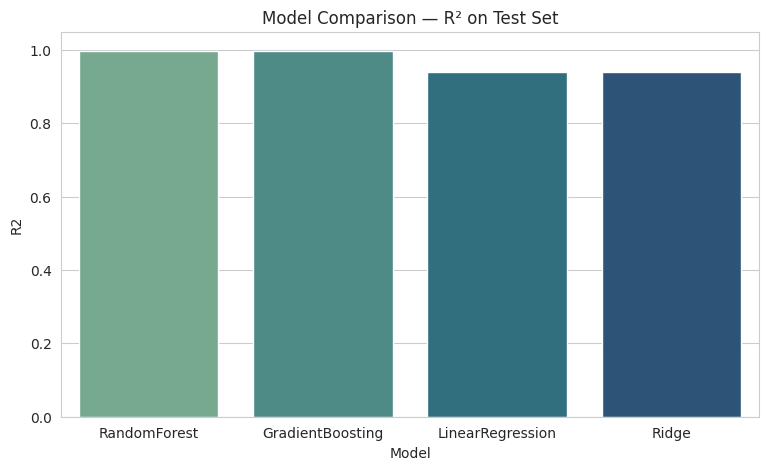

In [20]:
plt.figure(figsize=(9,5))
sns.barplot(data=results_df, x='Model', y='R2', palette='crest')
plt.title('Model Comparison — R² on Test Set')
plt.ylim(0,1.05)
plt.show()


## 7. Hyperparameter Tuning


In [22]:
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 15],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

rf_pipe = Pipeline([('pre', preprocessor), ('model', RandomForestRegressor(random_state=42))])

grid_search = GridSearchCV(
    rf_pipe, param_grid, cv=3, scoring='neg_mean_absolute_error',
    n_jobs=-1, verbose=0
)
grid_search.fit(X_train, y_train)

print('Best params:', grid_search.best_params_)
print('Best CV MAE:', -grid_search.best_score_)


Best params: {'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best CV MAE: 149.8095001800532


In [23]:
best_model = grid_search.best_estimator_
preds = best_model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)
print(f'Tuned RandomForest — MAE: {mae:.1f}, RMSE: {rmse:.1f}, R2: {r2:.4f}')


Tuned RandomForest — MAE: 121.3, RMSE: 185.8, R2: 0.9977


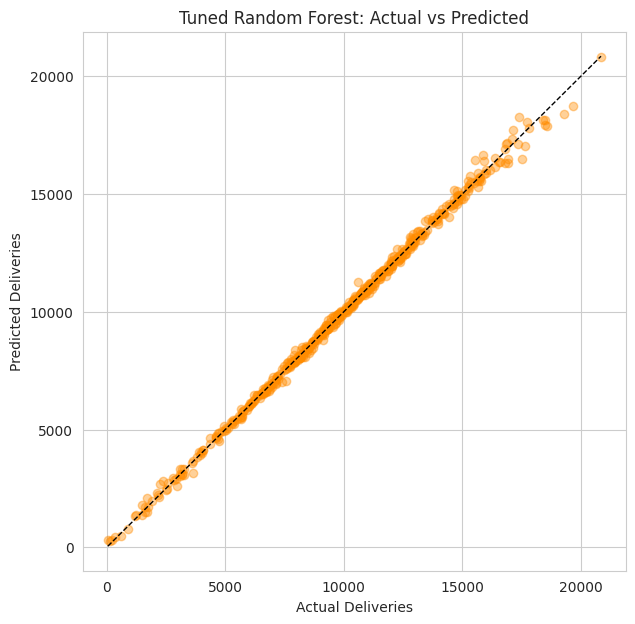

In [24]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, preds, alpha=0.4, color='darkorange')
lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
plt.plot(lims, lims, 'k--', lw=1)
plt.xlabel('Actual Deliveries')
plt.ylabel('Predicted Deliveries')
plt.title('Tuned Random Forest: Actual vs Predicted')
plt.show()


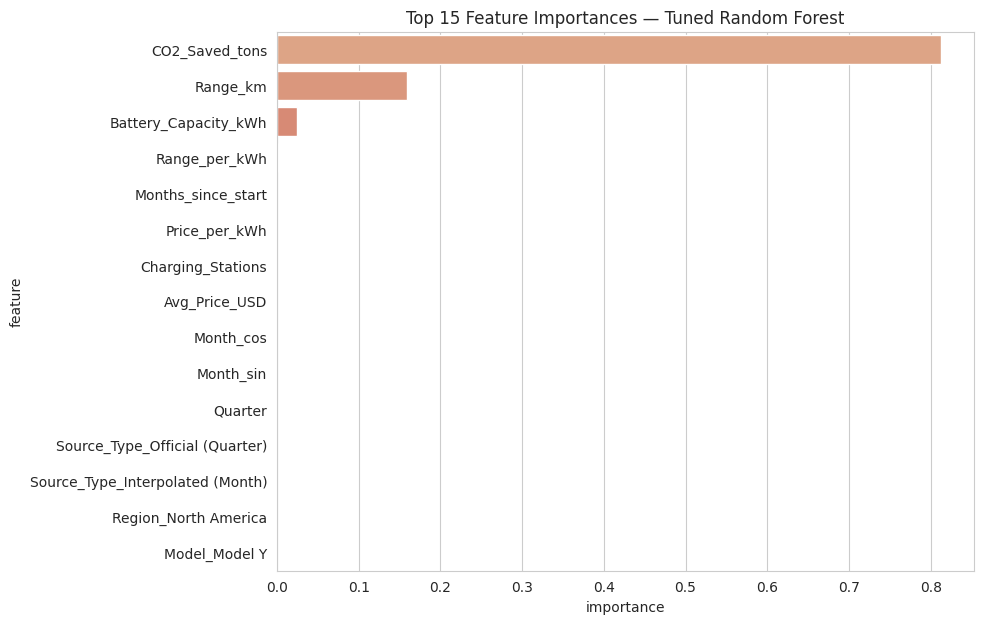

In [25]:
importances = best_model.named_steps['model'].feature_importances_
feature_names = (num_features +
    list(best_model.named_steps['pre'].named_transformers_['cat'].get_feature_names_out(cat_features)))
imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(9,7))
sns.barplot(data=imp_df, y='feature', x='importance', palette='flare')
plt.title('Top 15 Feature Importances — Tuned Random Forest')
plt.show()


## 8. Time Series Forecasting


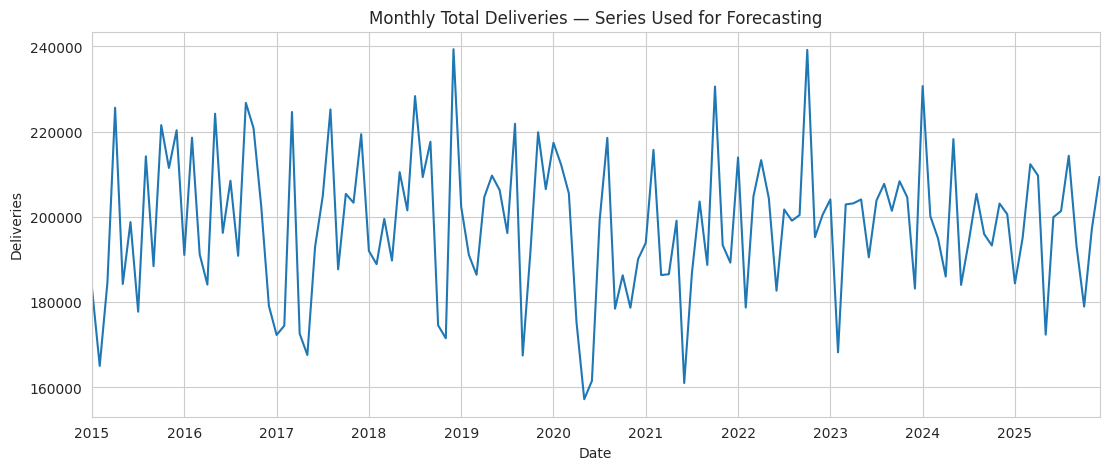

In [26]:
monthly = df.groupby('Date')['Estimated_Deliveries'].sum().sort_index().asfreq('MS')
monthly.plot(figsize=(13,5), title='Monthly Total Deliveries — Series Used for Forecasting')
plt.ylabel('Deliveries')
plt.show()


In [27]:
train_ts = monthly.iloc[:-12]
test_ts = monthly.iloc[-12:]

sarima_model = SARIMAX(train_ts, order=(1,1,1), seasonal_order=(1,1,1,12),
                        enforce_stationarity=False, enforce_invertibility=False)
sarima_res = sarima_model.fit(disp=False)
print(sarima_res.summary().tables[0])


                                     SARIMAX Results                                      
Dep. Variable:               Estimated_Deliveries   No. Observations:                  120
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -1061.796
Date:                            Sun, 28 Jun 2026   AIC                           2133.592
Time:                                    13:09:41   BIC                           2146.255
Sample:                                01-01-2015   HQIC                          2138.705
                                     - 12-01-2024                                         
Covariance Type:                              opg                                         


In [28]:
forecast = sarima_res.get_forecast(steps=12)
pred_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

ts_mae = mean_absolute_error(test_ts, pred_mean)
ts_rmse = np.sqrt(mean_squared_error(test_ts, pred_mean))
print(f'Holdout (last 12 months) — MAE: {ts_mae:.0f}, RMSE: {ts_rmse:.0f}')


Holdout (last 12 months) — MAE: 15247, RMSE: 19002


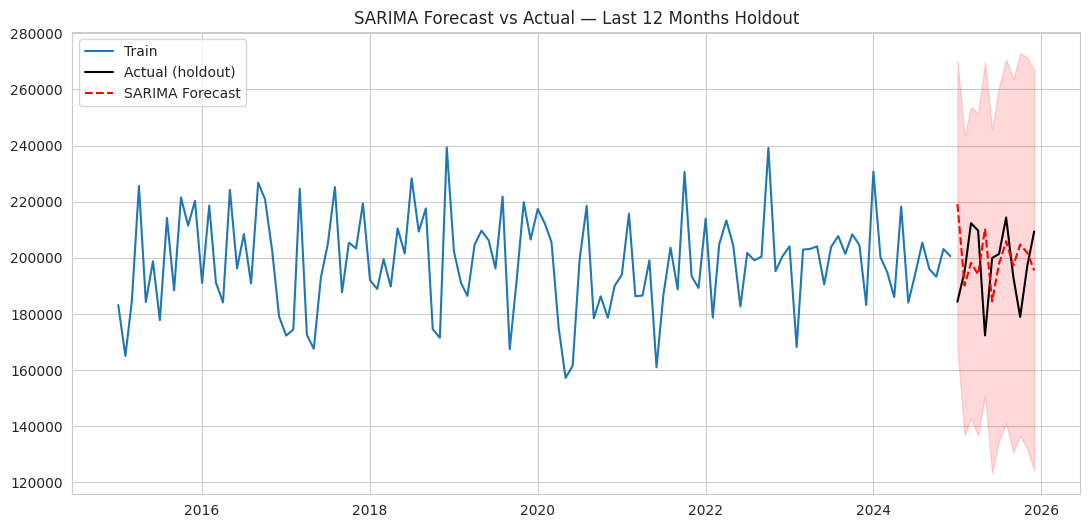

In [29]:
plt.figure(figsize=(13,6))
plt.plot(train_ts.index, train_ts.values, label='Train')
plt.plot(test_ts.index, test_ts.values, label='Actual (holdout)', color='black')
plt.plot(pred_mean.index, pred_mean.values, label='SARIMA Forecast', color='red', linestyle='--')
plt.fill_between(conf_int.index, conf_int.iloc[:,0], conf_int.iloc[:,1], color='red', alpha=0.15)
plt.title('SARIMA Forecast vs Actual — Last 12 Months Holdout')
plt.legend()
plt.show()


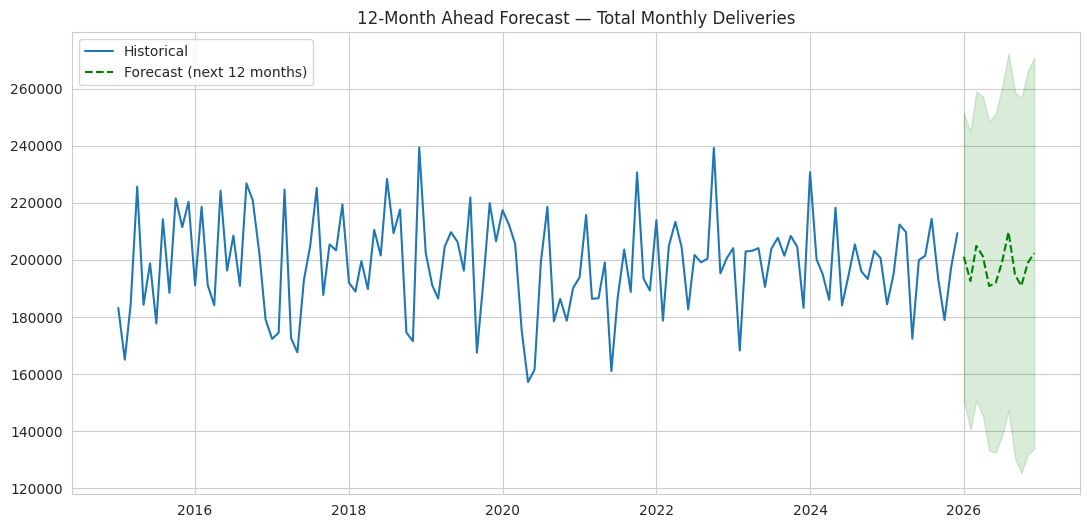

,Forecasted_Deliveries
2026-01-01,201096.0
2026-02-01,192608.0
2026-03-01,204893.0
2026-04-01,201319.0
2026-05-01,190842.0
2026-06-01,191864.0
2026-07-01,199112.0
2026-08-01,209791.0
2026-09-01,194750.0
2026-10-01,190906.0


In [30]:
full_model = SARIMAX(monthly, order=(1,1,1), seasonal_order=(1,1,1,12),
                      enforce_stationarity=False, enforce_invertibility=False)
full_res = full_model.fit(disp=False)
future_fc = full_res.get_forecast(steps=12)
future_mean = future_fc.predicted_mean
future_ci = future_fc.conf_int()

plt.figure(figsize=(13,6))
plt.plot(monthly.index, monthly.values, label='Historical')
plt.plot(future_mean.index, future_mean.values, label='Forecast (next 12 months)', color='green', linestyle='--')
plt.fill_between(future_ci.index, future_ci.iloc[:,0], future_ci.iloc[:,1], color='green', alpha=0.15)
plt.title('12-Month Ahead Forecast — Total Monthly Deliveries')
plt.legend()
plt.show()

future_mean.to_frame('Forecasted_Deliveries').round(0)
